# <center> Линейная алгебра в контексте линейных методов. Практика.

## <center> Прогнозирование выработки газа на скважинах.

## Постановка задачи

У Василия, основателя компании «Газ-Таз-Ваз-Нефть», дела идут в гору: у него уже функционирует 200 скважин для добычи газа. В этом году он открывает 30 новых скважин. Однако в целях оптимизации расходов и повышения дохода Василию необходимо оценить, сколько денег будет приносить ему каждая из скважин, а также понять, какие факторы (параметры скважин) потенциально сильнее всего повлияют на объём добычи газа. Для этого Василий решил нанять вас как специалиста в области Data Science.

Василий представляет вам набор данных о добыче газа на своих скважинах. Файл с данными вы можете скачать на платформе.

**Признаки в данных:**

* Well — идентификатор скважины;
* Por — пористость скважины (%);
* Perm — проницаемость скважины;
* AI — акустический импеданс ($кг/м^2 * 10^6$);
* Brittle — коэффициент хрупкости скважины (%);
* TOC — общий органический углерод (%);
* VR — коэффициент отражения витринита (%);
* Prod — добыча газа в сутки (млн. кубических футов).

**Ваша задача** — построить регрессионную модель, которая прогнозирует выработку газа на скважине (целевой признак — Prod) на основе остальных характеристик скважины, и проинтерпретировать результаты вашей модели.

Разделим задачу на две части:
* В первой мы построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.
* Во второй мы займёмся построением модели полиномиальной регрессии с регуляризацией и посмотрим на итоговые результаты моделирования.


Импортируем необходимые библиотеки:

In [1]:
# Импорт библиотек
import numpy as np # для работы с массивами
import pandas as pd # для работы с DataFrame 
import seaborn as sns # библиотека для визуализации статистических данных
import matplotlib.pyplot as plt # для построения графиков
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
colors = sns.color_palette("Set1")
order_colors = [colors[2], colors[0]] + [color for i, color in enumerate(colors) if i not in [0, 2]]
sns.set_theme('notebook', style="whitegrid", palette=order_colors)
%matplotlib inline

Прочитаем исходные данные:

In [2]:
data = pd.read_csv('data/unconv.csv')
data.head()

,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
0,1,12.08,2.92,2.80,81.40,1.16,2.31,4165.196191
1,2,12.38,3.53,3.22,46.17,0.89,1.88,3561.146205
2,3,14.02,2.59,4.01,72.80,0.89,2.72,4284.348574
3,4,17.67,6.75,2.63,39.81,1.08,1.88,5098.680869
4,5,17.52,4.57,3.18,10.94,1.51,1.90,3406.132832


## Практика: линейная регрессия по методу наименьших квадратов

Для начала построим простейшую модель линейной регрессии, проанализируем результаты её работы и выберем наиболее значимые факторы для прогнозирования.

В первой части вам предстоит выполнить задания 5.0–5.6. Максимальное количество баллов, которое можно получить, — 9.

### Задание 5.0. (не оценивается)

Проведите небольшой разведывательный анализ, чтобы поближе познакомиться с исходными данными. Постройте несколько визуализаций, которые помогут вам понять, как устроены исходные признаки, а также смогут продемонстрировать взаимосвязь факторов. 

Сделайте промежуточные выводы из проведённого разведывательного анализа.

- В данных 200 наблюдений
- Признаков-предикторов: 7
- Целевая переменная: Prod
- Количество пропущенных значений в данных: 0

Выбросы (по правилу 1.5*IQR):
Perm    5
AI      2
VR      5

Основная статистическая информация:


,Well,Por,Perm,AI,Brittle,TOC,VR,Prod
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,14.991150,4.330750,2.968850,48.161950,0.990450,1.964300,4311.219852
std,57.879185,2.971176,1.731014,0.566885,14.129455,0.481588,0.300827,992.038414
min,1.000000,6.550000,1.130000,1.280000,10.940000,-0.190000,0.930000,2107.139414
25%,50.750000,12.912500,3.122500,2.547500,37.755000,0.617500,1.770000,3618.064513
50%,100.500000,15.070000,4.035000,2.955000,49.510000,1.030000,1.960000,4284.687348
75%,150.250000,17.402500,5.287500,3.345000,58.262500,1.350000,2.142500,5086.089761
max,200.000000,23.550000,9.870000,4.630000,84.330000,2.180000,2.870000,6662.622385


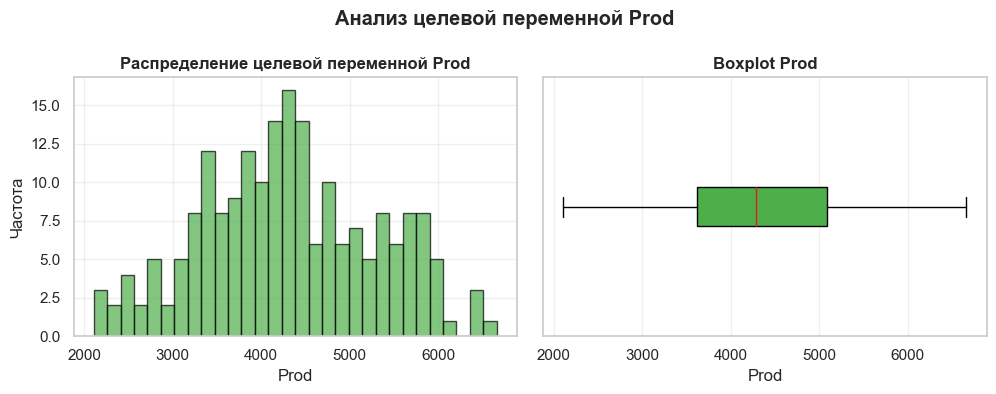

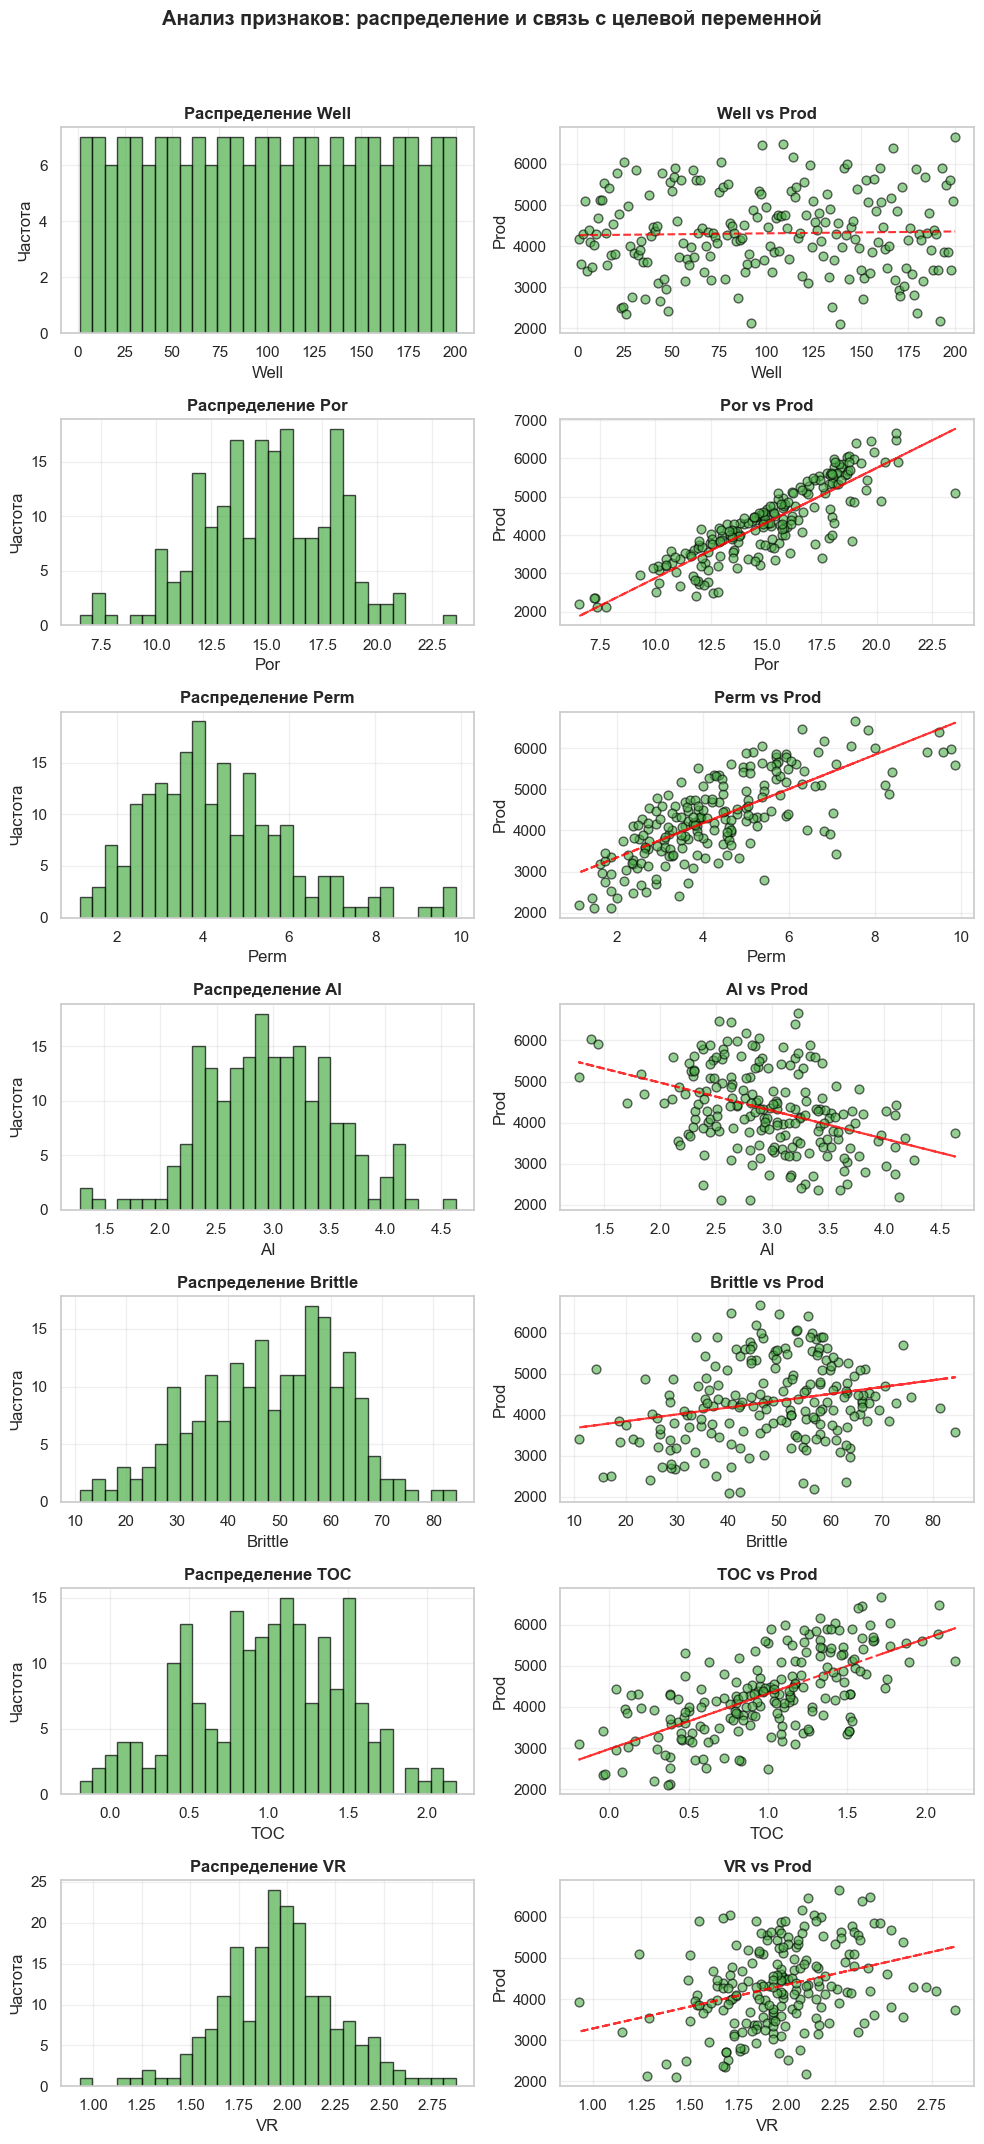

In [3]:
# Ваш код здесь
# Целевая переменная
target = 'Prod'
# Признаки (все, кроме целевой)
features = [col for col in data.columns if col != target]
print(f'- В данных {data.shape[0]} наблюдений')
print(f'- Признаков-предикторов: {len(features)}')
print(f'- Целевая переменная: {target}')

# Количество пропущенных значений
missing_data = data.isnull().sum()
print('- Количество пропущенных значений в данных:', missing_data.sum())

# Проверка выбросов
Q1 = data.quantile(0.25)
Q3 = data.quantile(0.75)
IQR = Q3 - Q1
outliers = ((data < (Q1 - 1.5 * IQR)) | 
            (data > (Q3 + 1.5 * IQR))).sum()
print("\nВыбросы (по правилу 1.5*IQR):")
print(outliers[outliers > 0].to_string())

# Статистика по признакам
print('\nОсновная статистическая информация:')
display(data.describe())

# Распределение целевой переменной
fig_target, (ax_hist_target, ax_box_target) = plt.subplots(1, 2, figsize=(10, 4))
# Гистограмма целевой переменной
ax_hist_target.hist(data[target], bins=30, edgecolor='black', alpha=0.7)
ax_hist_target.set_title(f'Распределение целевой переменной {target}', fontweight='bold')
ax_hist_target.set_xlabel(target)
ax_hist_target.set_ylabel('Частота')
ax_hist_target.grid(True, alpha=0.3)
# Boxplot целевой переменной
box_target = ax_box_target.boxplot(data[target], patch_artist=True, vert=False)
ax_box_target.set_title(f'Boxplot {target}', fontweight='bold')
ax_box_target.set_xlabel(target)
ax_box_target.set_yticks([])
ax_box_target.grid(True, alpha=0.3)
plt.suptitle(f'Анализ целевой переменной {target}', fontweight='bold')
plt.tight_layout()
plt.show()

# Визуализация признаков: гистограмма + scatter plot с целевой переменной
fig, axes = plt.subplots(len(features), 2, figsize=(10, 3*len(features)))
# Проходим по всем признакам-предикторам
for idx, col in enumerate(features):
    # Гистограмма признака (слева)
    ax_hist = axes[idx, 0]
    ax_hist.hist(data[col], bins=30, edgecolor='black', alpha=0.7)
    ax_hist.set_title(f'Распределение {col}', fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Частота')
    ax_hist.grid(True, alpha=0.3)
    
    # Scatter plot признака с целевой переменной (справа)
    ax_scatter = axes[idx, 1]
    ax_scatter.scatter(data[col], data[target], alpha=0.6, edgecolor='black', s=40)
    ax_scatter.set_title(f'{col} vs {target}', fontweight='bold')
    ax_scatter.set_xlabel(col)
    ax_scatter.set_ylabel(target)
    ax_scatter.grid(True, alpha=0.3)
    
    # Линия тренда
    z = np.polyfit(data[col], data[target], 1)
    p = np.poly1d(z)
    ax_scatter.plot(data[col], p(data[col]), "r--", alpha=0.8, linewidth=1.5)
plt.suptitle(
    'Анализ признаков: распределение и связь с целевой переменной',
    fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

*Качество данных*:
- Пропущенных значений в данных нет, данные чистые;
- Количество наблюдений соответствует идентификатору скважин в Well, т.е. Well простой счетчик наблюдений, а не категория, признак бесполезен для модели, необходимо его удалить;
- Все признаки числовые — преобразований данных не требуется.

*Распределения и связь с целевым*:
- Prod (добыча): сильно варьируется (около 2000-7000), распределение близко к нормальному;
- Well как было указано выше не несет никакой информации - идентификатор;
- Por близко к нормальному с лёгким правым скосом, демонстрирует очень сильную линейную связь с целевой переменной;
- Perm распределение скошено вправо, связь с целевым признаком сильная, но слегка скошена;
- TOC также довольно сильная связь с целевым признаком, распределение симметрично, близко к нормальному;
- AI, VR - связь с целевым признаком слабо выражена, распределения близки к нормальному;
- Brittle - имеет выраженный левосторонний скос, связь с целевой переменной визуально слабая.

*Выбросы*:
- Обнаружены в Perm (5), AI (2), VR (5)
- Prod без выбросов — что хорошо для построения модели
- Выбросы умеренные, можно оставить без обработки

Данные чистые и готовы к анализу. Признаки демонстрируют разнообразные распределения с умеренным количеством выбросов, что позволяет перейти к построению моделей прогнозирования добычи.

### Задание 5.1. (2 балла)

Постройте корреляционную матрицу факторов, включив в неё целевой признак. 

Для наглядности визуализируйте полученную матрицу с помощью тепловой карты. 

**Примечание.** *Для визуализации вы можете использовать любую из знакомых вам библиотек.*

На основе построенной корреляционной матрицы ответьте на следующий вопрос:

* Какие факторы сильнее всего коррелируют с целевой переменной?

Вычислите ранг и определитель полученной матрицы корреляций и приведите развёрнутые ответы на следующие вопросы:
* Является ли корреляционная матрица плохо обусловенной (близок ли её опредитель к нулю)?
* Что вы можете сказать о наличии коллинераности/мультиколлинеарности в данных? 
* Применима ли в данном случае модель классической линейной регрессии по методу наименьших квадратов и почему? 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для расчёта корреляционной матрицы;
    * приведён код для визуализации корреляционной матрицы в виде тепловой карты;
    * рассчитаны ранг и определитель корреляционной матрицы;
    * предоставлены обоснованные ответы на все поставленные вопросы. 

- Задание выполнено верно, но не учтено одно условие (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

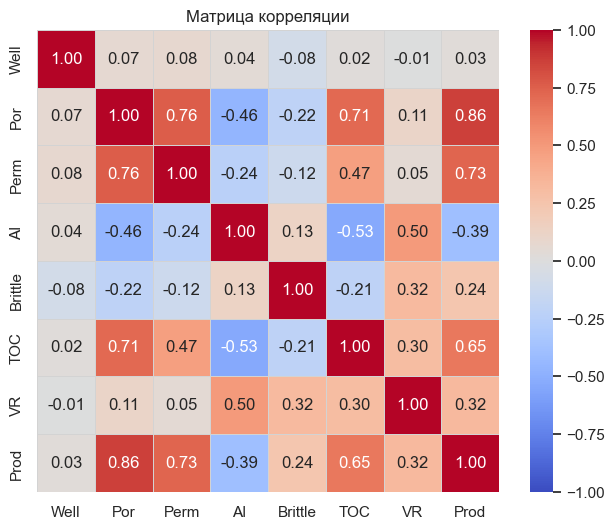

Ранг матрицы =  8
Определитель матрицы =  0.00073


In [4]:
# Ваш код здесь
# Вычисляю матрицу корреляции
data_corr = data.corr()
# Тепловая карта
fig = plt.figure(figsize=(8, 6))
fig = sns.heatmap(
    data_corr, annot=True, fmt='.2f', center=0, vmin=-1, vmax=1, square=True,
    linewidths=0.5, linecolor='lightgray', cmap='coolwarm'
)
fig.set_title('Матрица корреляции')
plt.show()

# Ранг матрицы
df_rank = np.linalg.matrix_rank(data_corr)
print('Ранг матрицы = ', df_rank)
# Определитель матрицы
df_det = np.linalg.det(data_corr)
print('Определитель матрицы = ', df_det.round(5))

*1. Корреляция с целевой переменной Prod:*
- Por (0.86), Perm (0.73) — сильная положительная корреляция
- TOC (0.65) — средняя положительная корреляция
- AI (-0.39), VR(0.32) — слабая корреляция
- Brittle (0.24) - очень слабая положительная связь.

*Вывод*: наиболее сильная связь с целевой переменной у Por, очень близок к 0.9. Perm и TOC демонстрируют сильную связь с целевой переменной.

*2. Анализ обусловленности матрицы*:
- Определитель = 0.00073 (близок к нулю)
- Ранг = 8 (при 8×8 матрице = полный ранг)

*Вывод*: матрица близка к вырожденной (плохо обусловлена).

*3. Наличие мультиколлинеарности*:
- Por–Perm (0.76) - сильная корреляционная связь
- Por-TOC (0.71) - сильная корреляционная связь

*Вывод*: хоть мультиколлинеарность отсутствует (нет корреляций >0.9), но наблюдается сильная связь между Por - Perm и Por-TOC, что может создавать нестабильность в оценках коэффициентов регрессии.

*4. Применимость классической линейной регрессии (МНК)*:
    
Матрица имеет полный ранг (8 из 8), определитель ненулевой, хоть и мал, значит теоретически модель линейной регрессии применима. Однако близость определителя к нулю может ухудшать устойчивость оценок. Рекомендуется применить регуляризацию или удалить сильно коррелирующие признаки.

### Задание 5.2. (2 балла)

Создайте матрицу наблюдений `X` и вектор правильных ответов `y`. В качестве факторов для матрицы наблюдений возьмите все имеющиеся в данных признаки. 

Постройте модель линейной регрессии по методу наименьших квадратов. Для этого воспользуйтесь матричной формулой МНК и инструментарием библиотеки numpy. 

Выведите на экран полученные оценки коэффициентов модели, округлённые до целого.

Приведите подробные выводы по полученным результатам, ответив на следующие вопросы:
* Есть ли в ваших данных признаки, которые, согласно модели, можно назвать неинформативными, то есть они не оказывают влияния на целевую переменную или оказывают шумовое влияние?
* Приведите интерпретацию нескольких (двух или трёх) коэффициентов полученной модели линейной регрессии.


**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * приведён код для нахождения параметров модели линейной регрессии с помощью матричной формулы МНК;
    * на основе полученных параметров даны верные ответы на поставленные вопросы;
    * приведена корректная интерпретация нескольких коэффициентов полученной модели линейной регрессии.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [5]:
# Ваш код здесь
# Вектор правильных ответов
y = data[['Prod']]
# Матрица наблюдений + интерсепт
X = np.column_stack([np.ones(200), data[features]])

# Вычисляем OLS-оценку для коэффициентов
w_hat=np.linalg.inv(X.T@X)@X.T@y
w_hat_list = w_hat.values[:,0]

print('Оценки коэффициентов модели линейной регрессии (округленные до целого):')
print(f"- Intercept (свободный член): {w_hat_list[0]:.0f}")
for i,feature in enumerate(features):
    print(f'- Для {feature} коэффициент модели линейной регрессии = {w_hat_list[i+1]:.0f}')

Оценки коэффициентов модели линейной регрессии (округленные до целого):
- Intercept (свободный член): -1232
- Для Well коэффициент модели линейной регрессии = 0
- Для Por коэффициент модели линейной регрессии = 230
- Для Perm коэффициент модели линейной регрессии = 116
- Для AI коэффициент модели линейной регрессии = -365
- Для Brittle коэффициент модели линейной регрессии = 25
- Для TOC коэффициент модели линейной регрессии = -78
- Для VR коэффициент модели линейной регрессии = 785


**Выводы**:
- Well: коэффициент = 0. Признак неинформативен (ожидаемо);
- Por, Perm, AI, VR - наибольший вклад в добычу, самые высокие коэффициенты;
- Brittle, TOC - относительно малые коэффициенты, возможна меньшая значимость;
- Por (230): увеличение пористости на 1% даёт +230 млн.куб.футов/сутки добычи;
- AI (-365): рост акустического импеданса снижает добычу на 365 млн.куб.футов/сутки;
- Perm (116): увеличение проницаемости на 1 единицу +116 млн.куб.футов/сутки;
- VR (785): увеличение коэффициента отражения витринита на 1% даёт самый сильный прирост добычи — 785 млн.куб.футов/сутки.

Наибольший коэффициент у VR (785) противоречит корреляционному анализу, где Por сильнее всего связан с добычей (0.86). Это указывает на нестабильность оценок из-за разных масштабов признаков или мультиколлинеарности. Для корректного сравнения влияния признаков требуется стандартизация данных.

### Задание 5.3. (1 балл)

Теперь потренируемся строить предсказание для наблюдений целевой переменной. 

**а)** Постройте прогноз выработки газа для скважины со следующими параметрами:

```python
{
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
 }
```

Рассчитайте абсолютную ошибку построенного вами прогноза для предложенной скважины (в миллионах кубических футов в день), если известно, что на этой скважине производится `4748.315024` миллионов кубических футов газа в день. 

**б)** Постройте прогноз выработки газа для всех скважин из обучающего набора данных. Выберите метрику, по которой вы будете оценивать качество регрессионных моделей и сравнивать их между собой (можно использовать несколько метрик, но не более двух).

Рассчитайте значение выбранной метрики для вашей модели. Приведите интерпретацию полученного результата. 

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**1 балл**): 
    * приведён код для построения прогноза выработки газа на указанной скважине и рассчитана абсолютная ошибка прогноза для этой скважины;
    * выбрана корректная для поставленной задачи метрика (или метрики) оценки качества модели и приведён код для расчёта этой метрики на всём обучающем наборе данных;
    * приведена корректная интерпретация полученного результата.

- Задание выполнено верно, но не учтено одно из условий, или задание выполнено неверно (**0 баллов**).

In [6]:
# Ваш код здесь
# Новая скважина
new_well = {
    'w0': 1,
    'Well': 106.0,
    'Por': 15.32,
    'Perm': 3.71,
    'AI': 3.29,
    'Brittle': 55.99,
    'TOC': 1.35,
    'VR': 2.42
}
new_well = np.array([*new_well.values()])
# Вычисление прогноза
new_well_predict = (new_well@w_hat).iloc[0]
print(f'Прогнозируемая выработка для новой скважины {new_well_predict:.0f} млн.куб.футов/сутки')
# Ошибки прогноза
new_well_real = 4748.315024
new_well_mae = abs(new_well_real - new_well_predict)
new_well_mape = (new_well_mae / new_well_real) * 100
print(f'Абсолютная ошибка прогноза MAE = {new_well_mae:.0f} млн.куб.футов/сутки')
print(f'Относительная ошибка прогноза MAPE = {new_well_mape:.2f} %')

# Предсказание для всех скважин
prediction = X@w_hat
# Расчет метрик
rmse = np.sqrt(((y - prediction)**2).mean())
mape = (abs((y - prediction) / y)).mean() * 100
# Вывод результатов
print('\nМетрики качества прогнозной модели:')
print(f'- Средняя абсолютная ошибка в процентах MAPE = {mape[0]:.2f} %')
print(f'- Корень из средней квадратической ошибки RMSE = {rmse[0]:.0f} млн.куб.футов/сутки')
print(f"- RMSE/Средняя добыча: {(rmse/y.mean()[0]*100)[0]:.1f}%")

Прогнозируемая выработка для новой скважины 4723 млн.куб.футов/сутки
Абсолютная ошибка прогноза MAE = 25 млн.куб.футов/сутки
Относительная ошибка прогноза MAPE = 0.53 %

Метрики качества прогнозной модели:
- Средняя абсолютная ошибка в процентах MAPE = 3.63 %
- Корень из средней квадратической ошибки RMSE = 198 млн.куб.футов/сутки
- RMSE/Средняя добыча: 4.6%


Так как заказчику Василию важно получить интерпретируемый результат работы модели, в качестве основных метрик выбраны MAPE которая в % демонстрирует среднюю относительную ошибку и RMSE корень из средней квадратической ошибки.  Первая в % укажет на ошибку модели. Вторая поможет Василию увидеть на сколько млн.куб.футов/сутки ошибается модель, при этом учтет большие отклонения в отличии от MAE. Справочно добавила отношение RMSE с средней величиной добычи, что добавит интерпретируемости результату.

**Выводы:**

1. Прогноз для конкретной скважины:
   - Прогнозируемая добыча: 4723 млн.куб.футов/сутки;
   - Реальная добыча: 4748 млн.куб.футов/сутки;
   - Абсолютная ошибка: 25 млн.куб.футов/сутки (0.53%);
   - Вывод: модель даёт высокоточный прогноз для новой скважины;

2. Общая оценка модели:
   - MAPE = 3.63%. Модель ошибается в среднем на 3,6%;
   - RMSE - средняя ошибка +/-198 млн.куб.футов/сутки (около 4.6% относительно средней добычи газа по всем скважинам);
   - Модель обладает достаточно высокой объясняющей способностью и в целом пригодна для прогнозирования добычи на новых скважинах.

### Задание 5.4. (1 балл)

Настало время анализа построенной модели. Посмотрите на коэффициенты и сравните их знаки со значениями выборочных корреляций между целевым признаком и факторами, которые вы нашли ранее.

Дайте развёрнутые ответы на следующие вопросы:

* Есть ли в вашей модели фактор, при котором коэффициент в модели линейной регрессии противоречит соответствующему коэффициенту корреляции? Например, корреляция говорит, что зависимость между фактором и целевой переменной прямая, а модель говорит обратное. Если таких факторов несколько, укажите их все.
* Как вы считаете, с чем связано полученное противоречие результатов?

**Критерии оценивания:**

- Задание выполнено верно, даны корректные развёрнутые ответы на все поставленные в задании вопросы (**1 балл**). 

- Задание выполнено неверно, даны некорректные ответы на один или несколько поставленных в задании вопросов (**0 баллов**).

In [7]:
# Ваш код здесь
# Таблица сравнения для признаков
comparison = pd.DataFrame({
    'Признак': features,
    'Корреляция с Prod': data_corr.loc[features, 'Prod'].values,
    'Коэффициент': w_hat_list[1:]
})

print("Сравнение корреляции и коэффициентов в модели:")
comparison.round(3).style.hide(axis="index")

Сравнение корреляции и коэффициентов в модели:


Признак,Корреляция с Prod,Коэффициент
Well,0.027000,0.051000
Por,0.862000,230.179000
Perm,0.727000,116.239000
AI,-0.391000,-365.202000
Brittle,0.237000,24.994000
TOC,0.654000,-78.401000
VR,0.323000,785.260000


**Вывод:**У признака TOC положительная корреляция с добычей (+0.65), но в модели он получил отрицательный коэффициент (-78.4). Направление влияния изменилось на противоположное. У признаков VR и AI корреляции с добычей слабые (+0.32 и +-0.39), но их коэффициенты в модели несоразмерно велики (+785 и -365). Это также указывает на проблему.

**Возможные причины**: TOC сильно коррелирует с Por (+0.71), который сам сильно влияет на добычу (+0.86). При такой взаимосвязи модель не может разделить индивидуальные вклады признаков. Por забирает основное положительное влияние, а другие признаки получают компенсирующие коэффициенты с искаженными знаками и масштабами.  Определитель матрицы признаков близок к нулю (0.00073), что подтверждает проблему. Кроме того, данные не стандартизированы, что также искажает результат.

**Итог**: Модель дает хорошие прогнозы, но интерпретация отдельных коэффициентов ненадежна. Отрицательный коэффициент TOC и завышенные коэффициенты VR и AI — это следствие мультиколлинеарности. Таким образом, результат модели нельзя назвать интерпретируемым, задача, поставленная Василием, не выполнена полностью.

### Задание 5.5. (2 балла)

* Исключите из данных сильно коррелированные между собой факторы. Под сильной корреляцией в данной задаче будем понимать значения выше `0.7`.

Выбирая, какой из коррелированных факторов оставить, руководствуйтесь коэффициентом корреляции с целевой переменной: оставляйте тот фактор, который больше всего коррелирует с целевой переменной (объёмом добычи газа).

* Также исключите из данных факторы, для которых корреляция с целевой переменной меньше `0.05`.

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого используйте матричную формулу и библиотеку numpy. Выведите значение полученных коэффициентов, округлённых до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте выбранную вами ранее метрику (или метрики). 

Дайте подробные ответы на следующие вопросы:

* Приведите интерпретацию нескольких полученных коэффициентов (двух или трёх). Сравните их значения с полученными ранее.
* Приведите интерпретацию полученных значений метрик. Сравните их значения с полученными ранее. 
* Удалось ли вам побороть противоречие коэффициентов линейной регрессии и коэффициентов корреляции?

**Критерии оценивания:**
- Задание выполнено верно, учтены все условия (**2 балла**): 
    * отобраны верные факторы;
    * на основе отобранных факторов построена модель линейной регрессии с помощью матричной формулы МНК и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * даны ответы на все поставленные в задании вопросы.

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено верно, не учтено несколько из условий (**0 баллов**).

In [8]:
# Ваш код здесь
""" 
Удаляю признаки Perm, TOC и Well. Por и Perm - 0.76 корреляция,
Por-TOC -  0.71 - корреляция, при этом Por сильнее коррелирует с целевой.
Well - отсутствует связь с целевой
""" 
# Подготовка данных
cols_for_drop = ['Perm', 'Well', 'TOC']
new_data = data[features].drop(cols_for_drop, axis=1)
# Матрица наблюдений + интерсепт
X = np.column_stack([np.ones(200), new_data])

# Вычисляем OLS-оценку для коэффициентов
w_hat_clean=np.linalg.inv(X.T@X)@X.T@y
w_hat_clean_list = w_hat_clean.values[:,0]
print('Оценки коэффициентов модели линейной регрессии (округленные до целого):')
print(f"- Intercept (свободный член): {w_hat_clean_list[0]:.0f}")
for i,feature in enumerate(new_data.columns):
    print(f'- Для {feature} коэффициент модели линейной регрессии = {w_hat_clean_list[i+1]:.0f}')
print("-"*45)

# Предсказание для всех скважин
prediction_clean = X@w_hat_clean
# Расчет метрик
rmse_clean = np.sqrt(((y - prediction_clean)**2).mean())
mape_clean = (abs((y - prediction_clean) / y)).mean() * 100
# Вывод результатов
print('\nМетрики качества прогнозной модели:')
print(f'- Средняя абсолютная ошибка в процентах MAPE = {mape_clean[0]:.2f} %')
print(f'- Корень из средней квадратической ошибки RMSE = {rmse_clean[0]:.0f} млн.куб.футов/сутки')
print(f"- RMSE/Средняя добыча: {(rmse_clean/y.mean()[0]*100)[0]:.1f}%")
print("-"*45)

# Таблица сравнения для признаков
comparison = pd.DataFrame({
    'Признак': new_data.columns,
    'Корреляция с Prod': data_corr.loc[new_data.columns, 'Prod'].values,
    'Коэффициент': w_hat_clean_list[1:]
})

print("\nСравнение корреляции и коэффициентов в модели:")
comparison.round(3).style.hide(axis="index")

Оценки коэффициентов модели линейной регрессии (округленные до целого):
- Intercept (свободный член): -1835
- Для Por коэффициент модели линейной регрессии = 293
- Для AI коэффициент модели линейной регрессии = -200
- Для Brittle коэффициент модели линейной регрессии = 28
- Для VR коэффициент модели линейной регрессии = 517
---------------------------------------------

Метрики качества прогнозной модели:
- Средняя абсолютная ошибка в процентах MAPE = 4.04 %
- Корень из средней квадратической ошибки RMSE = 232 млн.куб.футов/сутки
- RMSE/Средняя добыча: 5.4%
---------------------------------------------

Сравнение корреляции и коэффициентов в модели:


Признак,Корреляция с Prod,Коэффициент
Por,0.862000,293.036000
AI,-0.391000,-200.031000
Brittle,0.237000,27.641000
VR,0.323000,517.403000


**Выводы:**

1. Интерпретация коэффициентов (сравнение с предыдущей моделью):
    - Por: коэффициент увеличился с 230 до 293. После удаления Perm (сильно коррелировавшего с Por) "чистое" влияние пористости усилилось на 27%. Каждый процент увеличения пористости скважины приводит к росту добычи примерно на 293 млн.куб.футов/сутки;
    - AI: коэффициент снизился по модулю с 365 до 200. Влияние акустического импеданса ослабло в 1.8 раза, но знак остался отрицательным. Рост акустического импеданса на 1 единицу снижает добычу на 200 млн.куб.футов/сутки;
    - VR: коэффициент уменьшился с 785 до 517. Увеличение коэффициента отражения витринита на 1% даёт прирост добычи 517 млн.куб.футов/сутки (было 785). Коэффициент уменьшился на 34%, но остался высоким относительно слабой парной корреляции (0.32).

2. Сравнение метрик:
    - RMSE увеличился до 232 (было 198) млн.куб.футов/сутки, т.е. вырос на 17% (относительно средней добычи примерно на 1% (было 4.6% стало 5.4%));
    - MAPE также вырос до 4.04% (было 3.63%);
    - Точность модели немного снизилась, но это приемлемая плата за устранение мультиколлинеарности и повышение стабильности оценок.

3. Устранение противоречий:
    - Основное противоречие устранено. TOC исключен из модели, так как он сильно коррелировал с Por;
    - Знаки коэффициентов теперь соответствуют направлениям парных корреляций;
    - Проблема масштабов частично осталась. VR имеет коэффициент 517 при корреляции всего 0.32. Возможно связано с различиями в единицах измерения признаков и требует стандартизации;
    - Модель стала более интерпретируемой, но ее есть куда улучшать.

### Задание 5.6. (1 балл)

Наконец, давайте построим модель линейной регрессии из библиотеки `scikit-learn (sklearn)` и сравним результаты её работы с теми, что нам удалось получить вручную. 

Постройте модель линейной регрессии на обновлённых после удаления факторов данных по методу наименьших квадратов. Для этого воспользуйтесь классом `LinearRegression` из библиотеки `sklearn`. Выведите значения полученных коэффициентов, округлённые до целого.

Сделайте прогноз для всего обучающего набора данных и рассчитайте значение выбранной вами метрики (или метрик).

Сравните результаты библиотечной реализации с тем, что вы получили ранее. 

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов построена модель линейной регрессии из библиотеки sklearn и найдены параметры модели, соответствующие каждому из факторов;
    * построен прогноз для всего обучающего набора данных и рассчитано значение метрики (метрика должна быть выбрана корректно);
    * приведён вывод о соответствии результатов, полученных вручную и с помощью библиотеки.
- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [9]:
# Ваш код здесь

# Подготовка данных
X = new_data

# Создание и обучение модели
model = LinearRegression()
model.fit(X, y)

# Коэффициенты модели
print("Коэффициенты модели sklearn (округленные до целого):")
print(f"- Intercept (свободный член): {model.intercept_[0]:.0f}")
for i, feature in enumerate(new_data.columns):
    print(f"- Для {feature} коэффициент = {model.coef_[0,i]:.0f}")

# Прогноз на всем наборе данных
y_pred = model.predict(X)

# Расчет метрик
mse_lr = mean_squared_error(y, y_pred)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y, y_pred) * 100

print("\nМетрики качества модели sklearn:")
print(f"- MAPE = {mape_lr:.2f}%")
print(f"- RMSE = {rmse_lr:.0f}")
print(f"- RMSE/Средняя добыча: {(rmse_lr/y.mean()*100)[0]:.1f}%")

Коэффициенты модели sklearn (округленные до целого):
- Intercept (свободный член): -1835
- Для Por коэффициент = 293
- Для AI коэффициент = -200
- Для Brittle коэффициент = 28
- Для VR коэффициент = 517

Метрики качества модели sklearn:
- MAPE = 4.04%
- RMSE = 232
- RMSE/Средняя добыча: 5.4%


**Вывод**:

Модель линейной регрессии из библиотеки sklearn даёт идентичные результаты ручной реализации через матричную формулу МНК:
- Коэффициенты полностью совпадают
- Метрики MAPE и RMSE идентичны

Таким образом, подтверждена корректность матричных вычислений вручную.

## Практика: полиномиальная регрессия и регуляризация

Мы продолжаем работать над задачей от владельца компании «Газ-Таз-Ваз-Нефть» Василия.

Ранее мы построили модель линейной регрессии, которая прогнозирует выработку газа на скважине. Для этого мы с помощью матрицы корреляций и рассуждений отобрали некоррелированные, значимые для предсказания признаки. **Далее мы будем использовать именно их (см. задание 5.5).**

Мы хотим улучшить результат — уменьшить ошибку прогноза. Для этого мы воспользуемся моделью полиномиальной регрессии третьей степени. Однако теперь мы знаем, что полиномиальным моделям очень легко переобучиться под исходную выборку. Так как данных у нас не так много (всего 200 скважин), то для контроля качества модели мы будем использовать кросс-валидацию. 

Приступим! Выполните задания 8.1–8.5:


In [10]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate

### Задание 8.1. (1 балл)

Стандаризируйте признаки с помощью `StandartScaler` из библиотеки `sklearn`. 

Затем сгенерируйте полиномиальные признаки третьего порядка на факторах, которые вы выбрали для обучения моделей. Для этого воспользуйтесь генератором полиномов `PolynomialFeatures` из библиотеки `sklearn`. Параметр `include_bias` установите в значение `False`.

Выведите на экран, сколько факторов у вас получилось после генерации полиномиальных признаков.

**Важно:** стандартизацию необходимо произвести до генерации полиномиальных факторов!

Обучите модель линейной регрессии из библиотеки `sklearn` (`LinearRegression`) на полученных полиномиальных факторах.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * на основе отобранных факторов сгенерированы полиномиальные признаки третьего порядка;
    * построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).
- Задание выполнено неверно, не учтено одно или несколько из условий (**0 баллов**).

In [11]:
# Ваш код здесь
# Стандартизирую признаки
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)
# Получаю полиномиальные признаки
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(X_scaler)
print(f'Количество признаков после генерации полиномиальных признаков: {X_poly.shape[1]}')

# Создание и обучение модели
lr_model = LinearRegression()
# Метрики
scoring = {
    'mape': 'neg_mean_absolute_percentage_error',
    'rmse': 'neg_root_mean_squared_error'
}
# Кросс-валидация
cv = cross_validate(lr_model, X_poly, y, scoring=scoring, cv=5, return_train_score=True)

# Вывод результатов
print("\nМетрики качества модели:")
print('- MAPE на тренировочных фолдах: {:.2f} %'.format(-cv['train_mape'].mean()* 100))
print('- MAPE на валидационных фолдах: {:.2f} %'.format(-cv['test_mape'].mean() * 100)) 
print('- RMSE на тренировочных фолдах: {:.0f}'.format(-cv['train_rmse'].mean()))
print('- RMSE на валидационных фолдах: {:.0f}'.format(-cv['test_rmse'].mean())) 

Количество признаков после генерации полиномиальных признаков: 34

Метрики качества модели:
- MAPE на тренировочных фолдах: 1.77 %
- MAPE на валидационных фолдах: 2.68 %
- RMSE на тренировочных фолдах: 101
- RMSE на валидационных фолдах: 155


**Вывод**: Качество модели значительно улучшилось: MAPE снизился с 4.0% до 2.68% на валидационных данных. RMSE снизился с 231 до 154 на валидационных данных. Однако модель демонстрирует переобучение разница MAPE и RMSE между тренировочными и валидационными данными почти 1.5 раза. Таким образом, полиномиальная регрессия 3-го порядка существенно улучшила точность прогнозирования добычи, однако необходимо применить методы регуляризации для повышения обобщающей способности модели.

### Задание 8.2. (2 балла)

Теперь попробуем воспользоваться линейной регрессией с регуляризацией. Для начала возьмём $L_1$-регуляризацию.

Обучите модель `Lasso` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Lasso), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [12]:
# Ваш код здесь
# Используя GridSearchCV подбираю оптимальную alpha
param_grid = [{'alpha': list(np.linspace(0, 1, 5)) + list(np.linspace(2, 10, 9))}]

grid_search_lasso = GridSearchCV(
    estimator=Lasso(), 
    param_grid=param_grid, 
    cv=5,
    n_jobs = -1,
    # ранее уже задавала переменную scoring с искомыми метриками
    scoring=scoring,
    refit='rmse',
    return_train_score=True
)

# Обучаем модель (данные уже стандартизированы в предыдущем задании)
grid_search_lasso.fit(X_poly, y)

# Лучшая модель (по rmse метрике)
results = grid_search_lasso.cv_results_
best_index = grid_search_lasso.best_index_

# Вывод метрик лучшей модели
print(f"Лучшие параметры: {grid_search_lasso.best_params_}")
print("\nМетрики качества модели:")
print(f"- MAPE на тренировочных фолдах: {-results['mean_train_mape'][best_index]*100:.2f}%")
print(f"- MAPE на валидационных фолдах:  {-results['mean_test_mape'][best_index]*100:.2f}%")
print(f"- RMSE на тренировочных фолдах: {-results['mean_train_rmse'][best_index]:.0f}")
print(f"- RMSE на валидационных фолдах:  {-results['mean_test_rmse'][best_index]:.0f}")

Лучшие параметры: {'alpha': 6.0}

Метрики качества модели:
- MAPE на тренировочных фолдах: 1.85%
- MAPE на валидационных фолдах:  2.28%
- RMSE на тренировочных фолдах: 108
- RMSE на валидационных фолдах:  130


С помощью GridSearchCV был найден лучший параметр $\alpha = 6$. 

Благодаря $L_1$ регуляризации модель смогла снизить переобучение: 
- разница в метрике RMSE теперь составляет 22 млн. (130 на валидационных фолдах, 108 на тренировочных), т.е. около 20%, против 50% без регуляризации;
- разница в метриках MAPE между тренировочными и валидационными фолдами теперь составляет 23%, против 51% которые показывала модель без регуляризации;
- качество модели при этом не ухудшилось, повысилась обобщающая способность.

### Задание 8.3. (2 балла)

Проделаем то же самое с $L_2$-регуляризацией.

Обучите модель `Ridge` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициент регуляризации (`alpha`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию оцените среднее значение выбранной вами метрики (или метрик) на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

In [13]:
# Ваш код здесь
# Используя GridSearchCV подбираю оптимальную alpha
param_grid = [{'alpha': list(np.linspace(0, 1, 5)) + list(np.linspace(2, 10, 9))}]

grid_search_ridge = GridSearchCV(
    estimator=Ridge(), 
    param_grid=param_grid, 
    cv=5,
    n_jobs = -1,
    # ранее уже задавала переменную scoring с искомыми метриками
    scoring=scoring,
    refit='rmse',
    return_train_score=True
)

# Обучаем модель (данные уже стандартизированы в предыдущем задании)
grid_search_ridge.fit(X_poly, y)

# Лучшая модель (по rmse метрике)
results = grid_search_ridge.cv_results_
best_index = grid_search_ridge.best_index_

# Вывод метрик лучшей модели
print(f"Лучшие параметры: {grid_search_ridge.best_params_}")
print("\nМетрики качества модели:")
print(f"- MAPE на тренировочных фолдах: {-results['mean_train_mape'][best_index]*100:.2f}%")
print(f"- MAPE на валидационных фолдах:  {-results['mean_test_mape'][best_index]*100:.2f}%")
print(f"- RMSE на тренировочных фолдах: {-results['mean_train_rmse'][best_index]:.0f}")
print(f"- RMSE на валидационных фолдах:  {-results['mean_test_rmse'][best_index]:.0f}")

Лучшие параметры: {'alpha': 0.75}

Метрики качества модели:
- MAPE на тренировочных фолдах: 1.81%
- MAPE на валидационных фолдах:  2.70%
- RMSE на тренировочных фолдах: 102
- RMSE на валидационных фолдах:  153


С помощью GridSearchCV был найден лучший параметр $\alpha = 0.75$.

$L_2$-регуляризация не смогла существенно снизить переобучение модели:
- разница в метрике RMSE составляет 51 млн. (153 на валидационных фолдах, 102 на тренировочных), что сопоставимо с моделью без регуляризации (50%);
- разница в метриках MAPE между тренировочными и валидационными фолдами составляет 50%, что также соответствует результатам модели без регуляризации;
- качество модели осталось на прежнем уровне, обобщающая способность не улучшилась. 

$L_2$-регуляризация (Ridge) с оптимальным α=0.5 не улучшила качество модели, так как не исключает шумовые полиномиальные признаки. В отличие от L1 (Lasso), которая за счёт отбора признаков снизила переобучение и улучшила метрики. Для полиномиальных данных L1-регуляризация оказалась эффективнее.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (Ridge), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

### Задание 8.4. (2 балла)

Наконец, настало время комбинировать $L_1$ и $L_2$ -регуляризации.

Обучите модель `ElasticNet` из библиотеки `sklearn` на полученных полиномиальных факторах, предварительно стандартизировав факторы. 

Коэффициенты регуляризации (`alpha` и `l1-ratio`) подберите самостоятельно с помощью любого известного вам метода подбора гиперпаметров.

Используя кросс-валидацию, оцените среднее значение метрики MAPE на тренировочных и валидационных фолдах.

Проинтерпретируйте полученные результаты.

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**2 балла**): 
    * правильно построена модель полиномиальной регрессии (линейной регрессии на полиномиальных признаках) с регуляризацией (ElasticNet), учтены условия необходимости масштабирования факторов для построения модели;
    * приведён код для подбора параметра регуляризации (вручную или с помощью библиотечных инструментов);
    * с помощью кросс-валидации оценено среднее значение выбранной студентом метрики (или метрик) на тренировочных и валидационных фолдах (метрика должна быть выбрана корректно).

- Задание выполнено верно, но не учтено одно из условий (**1 балл**).
- Задание выполнено неверно, не учтено несколько условий (**0 баллов**).

In [14]:
# Ваш код здесь
# Используя GridSearchCV подбираю оптимальную alpha и l1-ratio
param_grid = [{
    'alpha': list(np.linspace(0, 1, 5)) + list(np.linspace(2, 10, 9)),
    'l1_ratio': list(np.linspace(0, 1, 5))
}]

grid_search_elastic = GridSearchCV(
    estimator=ElasticNet(), 
    param_grid=param_grid, 
    cv=5,
    n_jobs = -1,
    # ранее уже задавала переменную scoring с искомыми метриками
    scoring=scoring,
    refit='rmse',
    return_train_score=True
)

# Обучаем модель (данные уже стандартизированы в предыдущем задании)
grid_search_elastic.fit(X_poly, y)

# Лучшая модель (по rmse метрике)
results = grid_search_elastic.cv_results_
best_index = grid_search_elastic.best_index_

# Вывод метрик лучшей модели
print(f"Лучшие параметры: {grid_search_elastic.best_params_}")
print("\nМетрики качества модели:")
print(f"- MAPE на тренировочных фолдах: {-results['mean_train_mape'][best_index]*100:.2f}%")
print(f"- MAPE на валидационных фолдах:  {-results['mean_test_mape'][best_index]*100:.2f}%")
print(f"- RMSE на тренировочных фолдах: {-results['mean_train_rmse'][best_index]:.0f}")
print(f"- RMSE на валидационных фолдах:  {-results['mean_test_rmse'][best_index]:.0f}")

Лучшие параметры: {'alpha': 6.0, 'l1_ratio': 1.0}

Метрики качества модели:
- MAPE на тренировочных фолдах: 1.85%
- MAPE на валидационных фолдах:  2.28%
- RMSE на тренировочных фолдах: 108
- RMSE на валидационных фолдах:  130


> GridSearchCV в модели ElasticNet автоматически выбрал Lasso как оптимальный вариант, смешанная регуляризация не смогла улучшить результаты. Таким образом для нашего случая лучше всего $L_1$ регуляризация с параметром $\alpha = 6$.

### Задание 8.5. (1 балл)

Завершением вашей работы будет сводная таблица результатов, которую вы представите на презентации заказчику Василию.

Составьте таблицу (DataFrame) со следующими столбцами (имена столбцов выберите самостоятельно):
* Наименование модели.
* Гиперпараметры (коэффициенты регуляризации, если таковые имеются), если нет — оставьте ячейку пустой.
* Использовались ли полиномиальные признаки при построении модели (Да/Нет или True/False).
* Значение выбранной метрики на тренировочных фолдах при кросс-валидации модели.
* Значение выбранной метрики на валидационных фолдах при кросс-валидации модели.

Сделайте финальный вывод по проделанной работе. Какая линейная модель из тех, что мы рассмотрели, показала наилучший результат с точки зрения качества на валидационных фолдах, а также с точки зрения переобученности?

**Критерии оценивания:**

- Задание выполнено верно, учтены все условия (**1 балл**): 
    * верно составлена сводная таблица итоговых результатов построенных ранее моделей с указанными в задании столбцами;
    * приведены итоговые выводы по проделанной работе, указано, какая из рассмотренных моделей показала наилучший результат.

- Задание выполнено неверно, не учтено одно или несколько условий (**0 баллов**).

In [15]:
# Линейная на грязных данных
res1 = {
    'Model':'LinearRegression', 'Hyperparameters': None, 'Polynomial features':'No',
    'MAPE train':f'{mape[0]:.2f}%', 'MAPE valid':'-',
    'RMSE train':f'{rmse[0]:.0f}', 'RMSE valid':'-'
}
# Линейная после удаления коррелирующих признаков
res2 = {
    'Model':'LinearRegression after cleaned',
    'Hyperparameters': None, 'Polynomial features':'No',
    'MAPE train': f'{mape_clean[0]:.2f}%', 'MAPE valid':'-',
    'RMSE train': f'{rmse_clean[0]:.0f}', 'RMSE valid':'-'
}
# Полиномиальная
res3 = {
    'Model':'LinearRegression with Polynomial features',
    'Hyperparameters':None, 'Polynomial features':'Yes',
    'MAPE train':f"{-cv['train_mape'].mean()*100:.2f}%",
    'MAPE valid':f"{-cv['test_mape'].mean()*100:.2f}%",
    'RMSE train':f"{-cv['train_rmse'].mean():.0f}",
    'RMSE valid':f"{-cv['test_rmse'].mean():.0f}"
}

# Lasso, Ridge, ElasticNet
def get_res(name, gs):
    idx = gs.best_index_
    return {'Model': f'LinearRegression with {name}',
            'Hyperparameters': gs.best_params_, 'Polynomial features':'Yes',
            'MAPE train':f"{-gs.cv_results_['mean_train_mape'][idx]*100:.2f}%",
            'MAPE valid':f"{-gs.cv_results_['mean_test_mape'][idx]*100:.2f}%",
            'RMSE train':f"{-gs.cv_results_['mean_train_rmse'][idx]:.0f}",
            'RMSE valid':f"{-gs.cv_results_['mean_test_rmse'][idx]:.0f}"}

# Собираем
pivot_df = pd.DataFrame([res1, res2, res3,
                   get_res('Lasso', grid_search_lasso),
                   get_res('Ridge', grid_search_ridge),
                   get_res('ElasticNet', grid_search_elastic)])

# Отображаю
pivot_df.style.hide(axis="index")

Model,Hyperparameters,Polynomial features,MAPE train,MAPE valid,RMSE train,RMSE valid
LinearRegression,None,No,3.63%,-,198,-
LinearRegression after cleaned,None,No,4.04%,-,232,-
LinearRegression with Polynomial features,None,Yes,1.77%,2.68%,101,155
LinearRegression with Lasso,{'alpha': 6.0},Yes,1.85%,2.28%,108,130
LinearRegression with Ridge,{'alpha': 0.75},Yes,1.81%,2.70%,102,153
LinearRegression with ElasticNet,"{'alpha': 6.0, 'l1_ratio': 1.0}",Yes,1.85%,2.28%,108,130


**Финальный вывод**

1. Лучшая модель по качеству на валидационных данных — **LinearRegression with Lasso** (фактически ElasticNet с `alpha=6.0`, `l1_ratio=1.0`):
   - MAPE на валидации: 2.28%;
   - RMSE на валидации: 130 млн.куб.футов/сутки;
   - Эта модель показала наименьшую ошибку на валидации среди всех тестируемых.

2. С точки зрения смещения и разброса:
   - Разница между MAPE на тренировочных и валидационных данных у Lasso/ElasticNet составляет около 0.43%, что является наименьшим среди всех моделей с полиномиальными признаками;
   - Модель LinearRegression with Polynomial features (без регуляризации) имеет более высокий разрыв (0.91%), что указывает на переобучение;
   - Модели без полиномиальных признаков (первые две строки) имеют высокую ошибку на тренировочных данных, что говорит о недостаточной сложности модели;
   - Подбор гиперпараметров с помощью GridSearch для ElasticNet подтвердил, что лучших метрик достигает модель с $L_1$ регуляризацией, т.е. Lasso;
   - Ridge показал результат, близкий к модели без регуляризации, что может говорить о слабом влиянии L2-регуляризации в данном случае.

Итого рекомендуемая модель - LinearRegression with Lasso. Она сочетает в себе высокое качество предсказания (низкая MAPE и RMSE на валидации) и устойчивость к переобучению за счёт L1-регуляризации.